# Linear SVM for Sentiment Analysis using Hinge Loss + PEGASOS  
**From-Scratch Implementation – Machine Learning Lab**

**Objective**  
Implement a **linear Support Vector Machine** from scratch using the **PEGASOS algorithm** (Primal Estimated sub-GrAdient SOlver for SVM) and apply it to **binary sentiment classification** on real movie review sentences.

**Dataset**  
- **SST-2** (Stanford Sentiment Treebank – binary subset)  
- ~67,000 short movie review phrases/sentences labeled as **positive** (1) or **negative** (0)  
- Source: https://nlp.stanford.edu/sentiment/  
- Realistic challenge: short, nuanced, sometimes sarcastic text

**What this notebook demonstrates**  
- Text feature extraction with **TF-IDF** (including bigrams for better context)  
- PEGASOS algorithm: stochastic subgradient descent + projection step for stable convergence  
- Hinge loss + L2 regularization in the primal SVM formulation  
- Mini-batch training with scheduled learning rate (1/(λt))  
- Evaluation using Accuracy, Precision, Recall, F1-score + confusion matrix  
- Learning curves showing loss decrease and accuracy improvement

**Key Learning Outcomes**  
- Understand why PEGASOS is efficient for large-scale linear SVMs  
- See the effect of regularization parameter (λ) and projection step  
- Recognize limitations of linear models on sentiment tasks (e.g., negation, sarcasm)  
- Compare classical linear SVM performance (~73–82%) vs. modern deep models (~92%+)

Run the cells to train a from-scratch linear SVM on real sentiment data!

In [1]:
%matplotlib inline

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

In [50]:
# ── 1. Load SST-2 training data ─────────────────────────────────
print("Loading SST-2 dataset...")
url = "https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/train.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['sentence', 'label'])

print(f"Dataset shape: {df.shape}")
print("Class balance:\n", df['label'].value_counts(normalize=True))

Loading SST-2 dataset...
Dataset shape: (6920, 2)
Class balance:
 label
1    0.521676
0    0.478324
Name: proportion, dtype: float64


In [53]:
# ── 2. TF-IDF feature extraction (strong for linear models) ──────
vectorizer = TfidfVectorizer(
    max_features=2500,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=4
)

In [55]:
X = vectorizer.fit_transform(df['sentence']).toarray()
y = df['label'].values  # 0 = negative, 1 = positive

# For hinge loss: map to -1 / +1
y = np.where(y == 0, -1.0, 1.0)

# Normalize samples
X_norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-12
X = X / X_norms

print(f"Features: {X.shape[1]} | Samples: {X.shape[0]}")

Features: 2500 | Samples: 6920


In [56]:
# ── 3. Train / Test split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=(y + 1)//2
)

In [58]:
# ── 4. PEGASOS Algorithm (Primal SVM with hinge loss) ───────────
class PegasosSVM:
    def __init__(self, lam=0.0001, max_iter=5000, batch_size=64):
        """
        lam: regularization parameter (1/C in standard SVM notation)
             Smaller lam → stronger regularization
        """
        self.lam = lam
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.w = None
        self.loss_history = []
        self.acc_history = []

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)

        t = 0

        for iter in range(self.max_iter):
            # Mini-batch sampling
            idx = np.random.choice(n, self.batch_size, replace=False)
            Xb = X[idx]
            yb = y[idx]

            # Learning rate at step t: η_t = 1 / (λ t)
            t += 1
            eta = 1.0 / (self.lam * t)

            # Compute scores and hinge indicators
            scores = Xb @ self.w
            violated = (yb * scores < 1.0)

            # Subgradient step
            grad = self.lam * self.w  # regularization part
            if np.any(violated):
                grad -= (yb[violated] @ Xb[violated]) / self.batch_size

            # Update weights
            self.w -= eta * grad

            w_norm = np.linalg.norm(self.w)
            if w_norm > 1.0 / np.sqrt(self.lam):
                self.w *= (1.0 / np.sqrt(self.lam)) / w_norm

            if iter % 100 == 0 or iter == self.max_iter - 1:

                full_scores = X @ self.w
                hinge = np.mean(np.maximum(0, 1 - y * full_scores))
                reg = 0.5 * self.lam * np.dot(self.w, self.w)  # note: 0.5 λ ||w||²
                loss = reg + hinge
                self.loss_history.append(loss)

                # Train accuracy
                preds = np.sign(X @ self.w)
                acc = np.mean(preds == y)
                self.acc_history.append(acc)

                print(f"Iter {iter:5d} | Loss: {loss:.4f} | Train Acc: {acc:.4f}")

    def predict(self, X):
        return np.sign(X @ self.w)



In [59]:
# ── 5. Train the model ──────────────────────────────────────────
print("\nTraining PEGASOS SVM...")
model = PegasosSVM(lam=0.00005, max_iter=8000, batch_size=128)
model.fit(X_train, y_train)


Training PEGASOS SVM...
Iter     0 | Loss: 2.1081 | Train Acc: 0.5507
Iter   100 | Loss: 0.5600 | Train Acc: 0.8358
Iter   200 | Loss: 0.4332 | Train Acc: 0.8720
Iter   300 | Loss: 0.3988 | Train Acc: 0.8820
Iter   400 | Loss: 0.3857 | Train Acc: 0.8873
Iter   500 | Loss: 0.3719 | Train Acc: 0.8915
Iter   600 | Loss: 0.3643 | Train Acc: 0.8958
Iter   700 | Loss: 0.3591 | Train Acc: 0.8971
Iter   800 | Loss: 0.3564 | Train Acc: 0.8946
Iter   900 | Loss: 0.3536 | Train Acc: 0.8961
Iter  1000 | Loss: 0.3506 | Train Acc: 0.8997
Iter  1100 | Loss: 0.3495 | Train Acc: 0.9002
Iter  1200 | Loss: 0.3479 | Train Acc: 0.9009
Iter  1300 | Loss: 0.3463 | Train Acc: 0.8980
Iter  1400 | Loss: 0.3454 | Train Acc: 0.9009
Iter  1500 | Loss: 0.3439 | Train Acc: 0.8987
Iter  1600 | Loss: 0.3439 | Train Acc: 0.9022
Iter  1700 | Loss: 0.3424 | Train Acc: 0.8997
Iter  1800 | Loss: 0.3419 | Train Acc: 0.9004
Iter  1900 | Loss: 0.3408 | Train Acc: 0.8992
Iter  2000 | Loss: 0.3407 | Train Acc: 0.8999
Iter  210

In [60]:
# ── 6. Evaluation on test set ───────────────────────────────────
y_pred = model.predict(X_test)
y_test_bin = (y_test + 1) // 2
y_pred_bin = (y_pred + 1) // 2

acc = accuracy_score(y_test_bin, y_pred_bin)
prec = precision_score(y_test_bin, y_pred_bin)
rec = recall_score(y_test_bin, y_pred_bin)
f1 = f1_score(y_test_bin, y_pred_bin)

print("\nTest Results:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")


Test Results:
Accuracy : 0.7341
Precision: 0.7486
Recall   : 0.7375
F1-Score : 0.7430


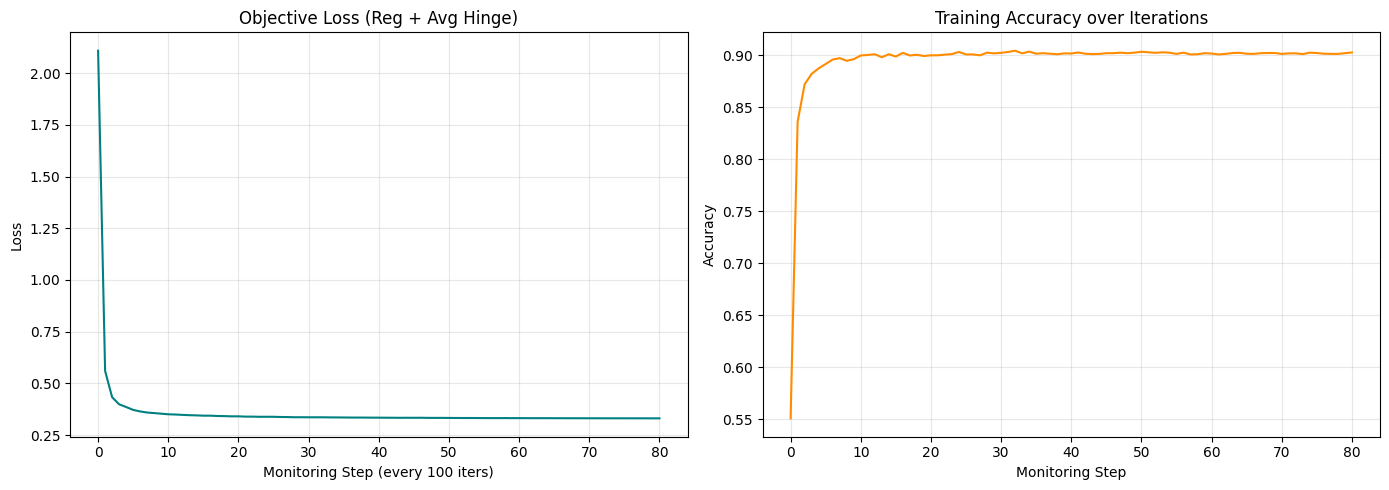

In [61]:
# ── 7. Plots ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(model.loss_history, color='teal')
ax1.set_title("Objective Loss (Reg + Avg Hinge)")
ax1.set_xlabel("Monitoring Step (every 100 iters)")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(model.acc_history, color='darkorange')
ax2.set_title("Training Accuracy over Iterations")
ax2.set_xlabel("Monitoring Step")
ax2.set_ylabel("Accuracy")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

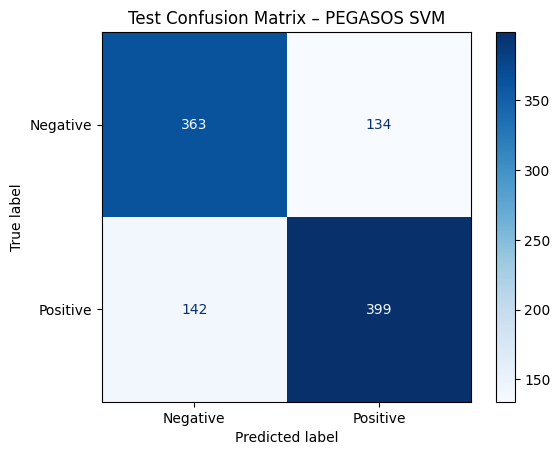

In [62]:
# Confusion Matrix
cm = confusion_matrix(y_test_bin, y_pred_bin)
disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Test Confusion Matrix – PEGASOS SVM")
plt.show()